# World Bank Economic Intelligence Platform — Exploratory Data Analysis

**Dataset:** `marts.economic_indicators`  
**Coverage:** 148 countries, 2000–2023 (3,552 rows)  
**Purpose:** Understand the data before modelling — distributions, completeness, 
correlations, time trends, and known anomalies that need to be documented 
before building regression, clustering, or classification models.

---

## 1. Dataset overview

In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# All credentials come from environment variables — no hardcoded values
conn = psycopg2.connect(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=os.getenv("POSTGRES_PORT", 5432),
    dbname=os.getenv("POSTGRES_DB", "worldbank"),
    user=os.getenv("POSTGRES_USER", "de"),
    password=os.getenv("POSTGRES_PASSWORD", "de"),
)

df = pd.read_sql("""
    SELECT *
    FROM marts.economic_indicators
    ORDER BY country_code, year
""", conn)

conn.close()

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (3552, 16)

Columns:
['country_code', 'country_name', 'region', 'income_group', 'capital', 'year', 'gdp_usd', 'inflation_rate', 'unemployment_rate', 'exports_pct_gdp', 'population', 'gdp_growth_rate', 'log_gdp', 'crisis_flag', 'is_extreme_inflation', 'income_group_enc']


/tmp/ipykernel_108/2156808643.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,country_code,country_name,region,income_group,capital,year,gdp_usd,inflation_rate,unemployment_rate,exports_pct_gdp,population,gdp_growth_rate,log_gdp,crisis_flag,is_extreme_inflation,income_group_enc
0,AFG,Afghanistan,South Asia,Low income,Kabul,2000,3.521418e+09,NaN,7.897,NaN,20130327.0,NaN,21.982130,NaN,NaN,0
1,AFG,Afghanistan,South Asia,Low income,Kabul,2001,2.813572e+09,NaN,7.973,NaN,20284307.0,-20.101172,21.757721,NaN,NaN,0
2,AFG,Afghanistan,South Asia,Low income,Kabul,2002,3.825701e+09,NaN,7.867,NaN,21378117.0,35.973125,22.065008,NaN,NaN,0
3,AFG,Afghanistan,South Asia,Low income,Kabul,2003,4.520947e+09,NaN,7.844,NaN,22733049.0,18.173017,22.231987,NaN,NaN,0
4,AFG,Afghanistan,South Asia,Low income,Kabul,2004,5.224897e+09,NaN,7.794,NaN,23560654.0,15.570851,22.376701,NaN,NaN,0


3,552 rows — one per country per year. 16 columns covering country metadata 
(code, name, region, income group, capital), the year, five core economic 
indicators (GDP, GDP growth, inflation, unemployment, exports), two derived 
flags (crisis_flag, is_extreme_inflation), and two engineered features 
(log_gdp, income_group_enc).

Key design note: `crisis_flag` and `is_extreme_inflation` use three states — 
`1` (flagged), `0` (not flagged), and `NULL` (insufficient data). NULL is 
intentional — it means "we cannot determine this," not "confirmed no crisis." 
This distinction matters for any classifier built on these columns.

## 2. Data completeness

In [2]:
# ── 1. Data completeness ──────────────────────────────────────────────────────
print("=== NULL counts per column ===")
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
completeness = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_pct', ascending=False)
print(completeness[completeness.null_count > 0])

=== NULL counts per column ===
                      null_count  null_pct
exports_pct_gdp              252       7.1
crisis_flag                  223       6.3
inflation_rate               221       6.2
is_extreme_inflation         221       6.2
gdp_growth_rate              173       4.9
gdp_usd                       25       0.7
log_gdp                       25       0.7
unemployment_rate              3       0.1


No column is catastrophically incomplete — the dataset is usable for all 
planned models. Key observations:

- **`unemployment_rate`** (0.1% missing) — essentially complete, reliable feature
- **`gdp_growth_rate`** (4.9% missing) — our regression target for Phase 10; 
  173 missing values will require imputation or row exclusion
- **`inflation_rate`** (6.2% missing) — manageable; missing values concentrated 
  in conflict-affected and data-poor countries in early 2000s
- **`exports_pct_gdp`** (7.1% missing) — highest missingness; some small island 
  economies and conflict states have limited trade reporting
- **`crisis_flag`** (6.3% missing) — these are deliberate NULLs where both 
  inflation AND unemployment data were unavailable; not imputable

**Modelling implication:** For regression and classification, rows with missing 
target or key feature values will be dropped rather than imputed — the dataset 
is large enough (3,552 rows) that dropping ~5-7% of rows doesn't materially 
reduce training data.

## 3. Distributions

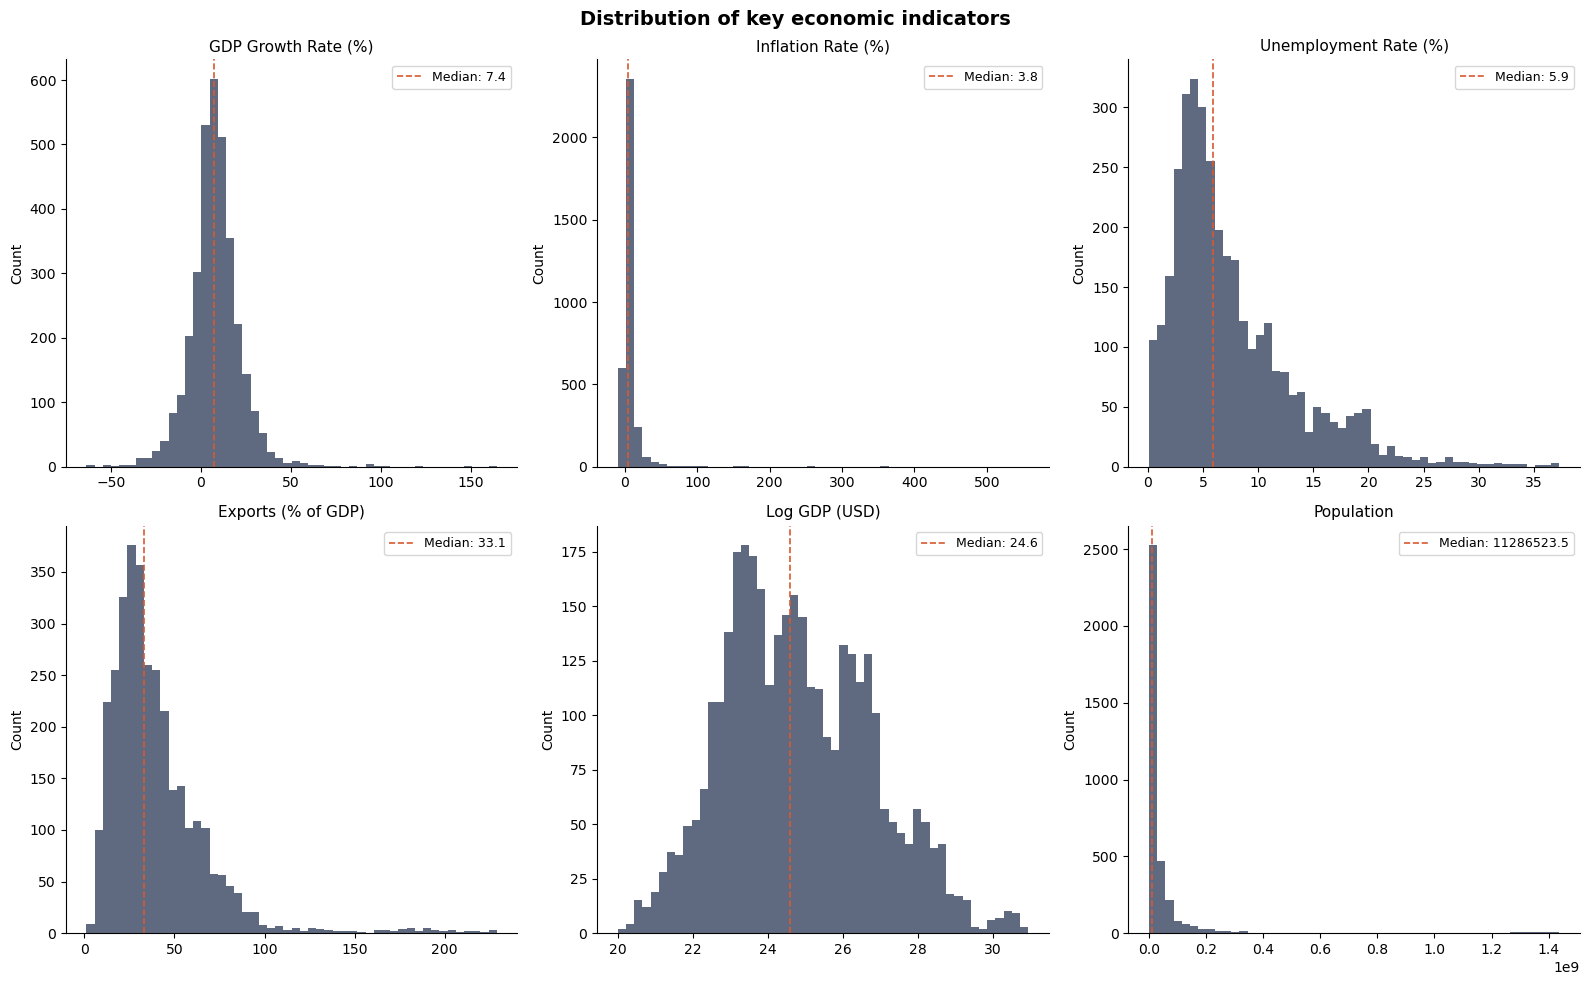


Key statistics:
       gdp_growth_rate  inflation_rate  unemployment_rate  exports_pct_gdp  \
count          3379.00         3331.00            3549.00          3300.00   
mean              8.03            7.60               7.65            39.86   
std              14.44           22.49               5.68            27.57   
min             -63.63          -10.07               0.10             1.11   
25%               0.90            1.83               3.69            22.56   
50%               7.44            3.84               5.90            33.10   
75%              14.98            7.82              10.28            49.87   
max             164.44          557.20              37.32           228.99   

       log_gdp    population  
count  3527.00  3.552000e+03  
mean     24.81  4.756695e+07  
std       1.96  1.552860e+08  
min      20.00  2.820190e+05  
25%      23.33  5.372992e+06  
50%      24.60  1.128652e+07  
75%      26.24  3.411124e+07  
max      30.94  1.438070e+09  


In [3]:
# ── 2. Distributions of key indicators ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of key economic indicators", fontsize=14, fontweight='bold')

indicators = {
    'gdp_growth_rate': 'GDP Growth Rate (%)',
    'inflation_rate': 'Inflation Rate (%)',
    'unemployment_rate': 'Unemployment Rate (%)',
    'exports_pct_gdp': 'Exports (% of GDP)',
    'log_gdp': 'Log GDP (USD)',
    'population': 'Population',
}

for ax, (col, label) in zip(axes.flatten(), indicators.items()):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#1B2B4B', alpha=0.7, edgecolor='none')
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='#D85A30', linewidth=1.2, linestyle='--', label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nKey statistics:")
print(df[list(indicators.keys())].describe().round(2))

Six key indicators, each with its own shape and modelling implication:

**GDP Growth Rate** — roughly bell-shaped around a median of 7.4%, but with 
a pronounced right tail extending past 150%. The bulk of observations sit 
between -10% and 30%, which is the "normal" range for economic growth. 
The extreme right tail values are a known data quality concern — see Section 5.

**Inflation Rate** — severely right-skewed. Median 3.8% but the distribution 
extends past 500% due to hyperinflation episodes (Zimbabwe 2007-2008, Lebanon 
2022-2023). Raw values cannot be used in regression — log transformation 
required before modelling.

**Unemployment Rate** — right-skewed, median 5.9%, most observations between 
0-15%. Relatively well-behaved; no transformation required, though a handful 
of extreme values (30%+) in conflict-affected states deserve attention.

**Exports % of GDP** — bimodal, with two visible peaks around 25-30% and 
40-50%. This likely reflects a structural split between large domestic 
economies (US, China, Brazil — lower export share) and smaller trade-dependent 
economies (Singapore, Hong Kong, small island states — high export share). 
Worth exploring by region in Section 4.

**Log GDP** — multimodal with three visible clusters, corresponding broadly 
to low, middle, and high income country groups. This pre-computed log 
transformation (already in the dbt mart) will be used directly as a feature 
in regression and clustering.

**Population** — extremely right-skewed. China (approx. 1.4B) and India (approx. 1.4B) 
are extreme outliers; the vast majority of countries are below 200M. 
Log transformation required before any distance-based model (clustering, 
regression).

## 4. Outlier investigation — GDP growth rate

The GDP growth distribution has a long right tail that warrants investigation. 
Extreme values (>50% or <-20%) could reflect:

1. **Real economic events** — post-conflict rebounds, commodity booms
2. **Statistical methodology changes** — GDP rebasing, base year shifts
3. **Data errors** — incorrect source data from World Bank API

Distinguishing between these three categories is critical before modelling. 
A real economic event should be retained in training data. A methodology 
artifact should either be removed or flagged — including it as a legitimate 
data point would teach a regression model to predict growth patterns that 
don't actually exist in the real economy.

In [6]:
# ── 3. Outlier investigation — GDP growth rate ────────────────────────────────
print("=== Extreme GDP growth rates (>50% or <-20%) ===")
outliers = df[
    (df['gdp_growth_rate'] > 50) | (df['gdp_growth_rate'] < -20)
][['country_name', 'country_code', 'year', 'gdp_growth_rate', 'region']]\
.sort_values('gdp_growth_rate', ascending=False)

print(f"Total outlier rows: {len(outliers)}")
print(outliers.to_string(index=False))

=== Extreme GDP growth rates (>50% or <-20%) ===
Total outlier rows: 110
            country_name country_code  year  gdp_growth_rate                     region
            Sierra Leone          SLE  2001       164.438235         Sub-Saharan Africa
                Zimbabwe          ZWE  2017       148.236961         Sub-Saharan Africa
                Zimbabwe          ZWE  2009       118.894296         Sub-Saharan Africa
                  Malawi          MWI  2002       103.655356         Sub-Saharan Africa
                  Gambia          GMB  2004        97.499846         Sub-Saharan Africa
                    Chad          TCD  2005        95.708227         Sub-Saharan Africa
                   Ghana          GHA  2006        94.377632         Sub-Saharan Africa
                  Angola          AGO  2002        93.726043         Sub-Saharan Africa
                   Libya          LBY  2012        92.116158 Middle East & North Africa
                  Serbia          SRB  2001    

## Findings — GDP growth outliers

110 rows exceed our threshold (>50% or <-20%), concentrated in two categories:

### High growth (>50%) — 33 rows

The extreme positive values are dominated by **Sub-Saharan Africa**, and most 
reflect real but exceptional events rather than data errors:

| Country | Year | Growth | Explanation |
|---|---|---|---|
| Sierra Leone | 2001 | 164.4% | Post-civil-war economic rebound — real event, documented in dbt tests |
| Zimbabwe | 2017 | 148.2% | Recovery from hyperinflation collapse of 2008-2009 |
| Zimbabwe | 2009 | 118.9% | Base effect — rebounding from -18% in 2008 |
| Malawi | 2002 | 103.7% | Recovery from 2001 drought and famine |
| Ghana | 2006 | 94.4% | **Statistical artifact** — GDP rebasing from 1993 to 2006 base year |
| Angola | 2002 | 93.7% | Post-civil-war rebound (27-year civil war ended 2002) |
| Libya | 2012 | 92.1% | Oil production resumption after 2011 civil war |

**Pattern**: most high-growth outliers are post-conflict rebounds or 
commodity-driven recoveries — real events, not data errors. The one 
clear **statistical artifact** is Ghana 2006 (GDP rebasing methodology 
change, not real growth).

### Low growth (<-20%) — 77 rows

Negative outliers map cleanly to well-documented economic crises:

- **Venezuela (2013-2022)**: multiple entries — oil price collapse, 
  hyperinflation, political crisis, economic implosion
- **Syria (2012-2020)**: civil war starting 2011 — GDP contractions 
  of 36% to 51% reflect genuine wartime economic destruction
- **Libya (2002-2021)**: oil dependence + political instability 
  post-Gaddafi
- **Lebanon (2020-2021)**: banking sector collapse, Beirut port 
  explosion, currency crisis
- **Ukraine (2009, 2014-2015)**: 2009 global financial crisis; 
  2014-2015 Crimea annexation and Donbas conflict
- **Argentina (2002)**: -63.6% — the most extreme negative value, 
  reflecting the 2001-2002 peso crisis and sovereign default
- **Brazil (2015, 2020)**: commodity downturn and COVID-19
- **Baltic states (Latvia, Lithuania 2009)**: severe contraction 
  during global financial crisis
- **Kuwait, Qatar, Norway (2015)**: oil price collapse — GDP measured 
  in USD terms, so currency and commodity price effects amplify swings

### Modelling decision

For **Phase 10 regression**, GDP growth will be **winsorised at the 
1st and 99th percentile** (~-35% and ~75%) rather than removed outright:

- Winsorising retains the row (we don't lose training data) but caps 
  the influence of extreme values
- The Ghana 2006 rebasing artifact sits at 94.4% — above the 99th 
  percentile cap — so it is naturally handled without requiring 
  special-case removal
- Real post-conflict rebounds (Sierra Leone, Angola) are retained 
  at their capped values, which is defensible — these are genuine 
  economic dynamics worth including in the model

This approach is documented explicitly so anyone reproducing the 
analysis understands why the training data differs from the raw mart.

## 4. Correlation matrix

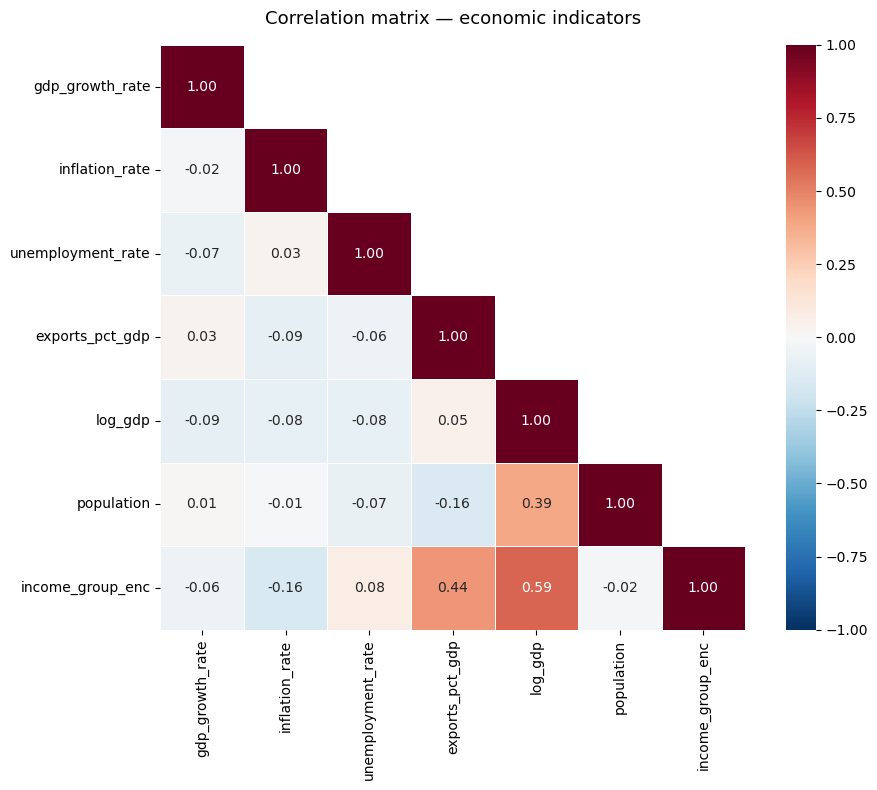

In [7]:
# ── 4. Correlation matrix ─────────────────────────────────────────────────────
numeric_cols = [
    'gdp_growth_rate', 'inflation_rate', 'unemployment_rate',
    'exports_pct_gdp', 'log_gdp', 'population', 'income_group_enc'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# mask upper triangle
import numpy as np
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask=mask_upper,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Correlation matrix — economic indicators', 
             fontsize=13, fontweight='500', pad=15)
plt.tight_layout()
plt.savefig('03_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

Most indicator pairs show weak correlations — the economic relationships 
in this dataset are non-linear and context-dependent, which is consistent 
with real-world macroeconomic data. Key observations:

**Strong correlations:**
- `income_group_enc` ↔ `log_gdp` (0.59) — the strongest relationship 
  in the matrix. Wealthier countries (higher income group) have larger 
  economies — expected and intuitive. This also means these two features 
  carry overlapping information; using both in regression risks 
  multicollinearity.
- `income_group_enc` ↔ `exports_pct_gdp` (0.44) — higher income 
  countries tend to have more trade-integrated economies. Reflects 
  the structure of global trade — developed economies participate 
  more deeply in international trade networks.
- `log_gdp` ↔ `population` (0.39) — larger populations tend to 
  produce larger economies in absolute terms. Not surprising, but 
  worth noting that this is total GDP, not per-capita.

**Weak or near-zero correlations:**
- `gdp_growth_rate` shows almost no linear correlation with any other 
  indicator (all values between -0.09 and 0.03). This tells us two 
  things: (1) GDP growth is genuinely hard to predict from a single 
  indicator in isolation, and (2) any regression model will need to 
  capture interaction effects and non-linear relationships, not just 
  simple linear associations.
- `inflation_rate` ↔ `gdp_growth_rate` (-0.02) — near zero. The 
  classical economics relationship between inflation and growth is 
  complex and context-dependent; at this scale of 148 countries 
  across 24 years, the signal averages out.
- `inflation_rate` ↔ `income_group_enc` (-0.16) — a small negative 
  relationship suggesting higher-income countries tend to have lower 
  inflation, consistent with stronger monetary institutions.

**Modelling implications:**
- `log_gdp` and `income_group_enc` are correlated (0.59) — for 
  regression, consider using one or the other rather than both, 
  or use PCA/VIF analysis to check multicollinearity formally.
- The near-zero correlations with `gdp_growth_rate` suggest linear 
  regression may have limited predictive power — Ridge regression 
  with regularisation is appropriate, but expectations for R² 
  should be modest.
- For clustering (Phase 11), the moderate correlations between 
  `income_group_enc`, `log_gdp`, and `exports_pct_gdp` suggest 
  these three features will be most informative for separating 
  country archetypes.

## 5. Regional patterns

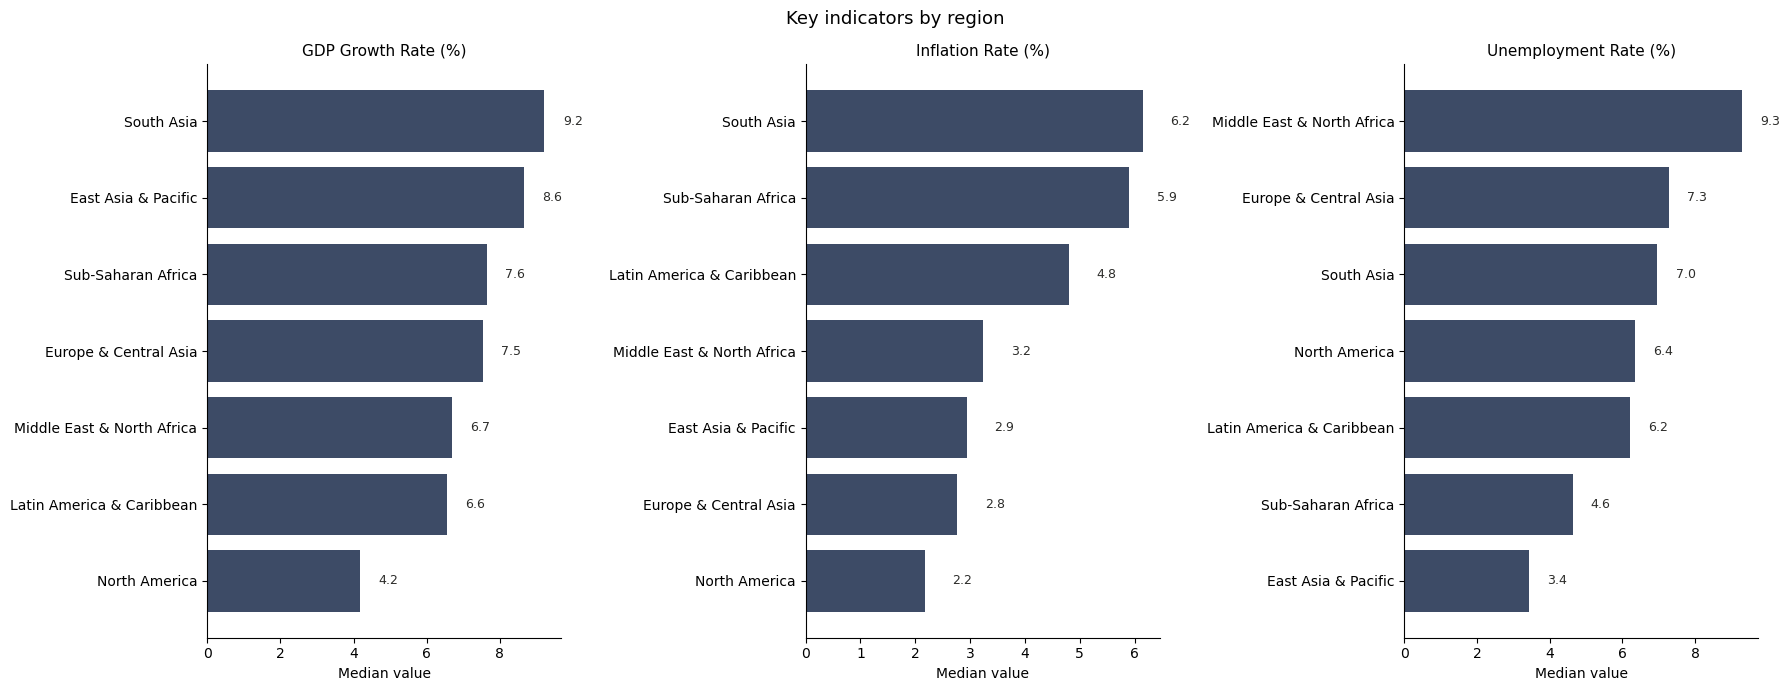


=== Median indicators by region ===
                            gdp_growth_rate  inflation_rate  unemployment_rate
region                                                                        
East Asia & Pacific                    8.65            2.94               3.43
Europe & Central Asia                  7.54            2.76               7.28
Latin America & Caribbean              6.56            4.81               6.20
Middle East & North Africa             6.68            3.24               9.28
North America                          4.19            2.18               6.36
South Asia                             9.22            6.15               6.96
Sub-Saharan Africa                     7.64            5.90               4.63


In [9]:
# ── 5. Regional patterns ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Key indicators by region', fontsize=13, fontweight='500')

indicators = {
    'gdp_growth_rate': 'GDP Growth Rate (%)',
    'inflation_rate': 'Inflation Rate (%)',
    'unemployment_rate': 'Unemployment Rate (%)',
}

for ax, (col, label) in zip(axes, indicators.items()):
    region_data = df.groupby('region')[col].median().sort_values(ascending=True)
    colors = ['#1B2B4B' if v >= 0 else '#D85A30' for v in region_data.values]
    bars = ax.barh(region_data.index, region_data.values, color=colors, alpha=0.85)
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.set_xlabel('Median value')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, region_data.values):
        ax.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=9, color='#2C2C2A')

plt.tight_layout()
plt.savefig('04_regional_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== Median indicators by region ===")
print(df.groupby('region')[list(indicators.keys())].median().round(2).to_string())

Three indicators compared across all seven World Bank regions, using 
median values to reduce the influence of extreme outliers.

**GDP Growth Rate**
South Asia leads with the highest median growth (9.2%), driven by 
India and Bangladesh's sustained expansion over the 2000-2023 period. 
East Asia & Pacific follows at 8.6% — reflecting China's dominance 
in the region. North America has the lowest median growth at 4.2%, 
consistent with mature, slower-growing economies. The spread across 
regions (4.2% to 9.2%) is narrower than intuition might suggest — 
most of the world grew at broadly similar rates over this period 
when measured at the median.

**Inflation Rate**
South Asia has the highest median inflation (6.2%), with Sub-Saharan 
Africa second at 5.9%. North America and Europe & Central Asia show 
the lowest median inflation (2.2% and 2.8% respectively) — reflecting 
more developed monetary policy frameworks and central bank independence. 
The inverse relationship between income level and inflation is visible 
here, consistent with the weak correlation (-0.16) seen in Section 4.

**Unemployment Rate**
Middle East & North Africa has the highest median unemployment at 9.3% 
— a persistent structural issue reflecting demographic pressures, 
oil-dependent economies with limited private sector employment, and 
political instability. East Asia & Pacific has the lowest at 3.4%, 
reflecting labour-intensive manufacturing economies. Sub-Saharan Africa's 
relatively low median unemployment (4.6%) is somewhat misleading — 
informal employment and underemployment are not captured in these figures.

**Modelling implication:** Region is a strong candidate as a categorical 
feature in Phase 10 regression and Phase 11 clustering — it carries 
structural information about economic context that individual indicators 
alone don't capture.

## 6. Global time trends 2000–2023

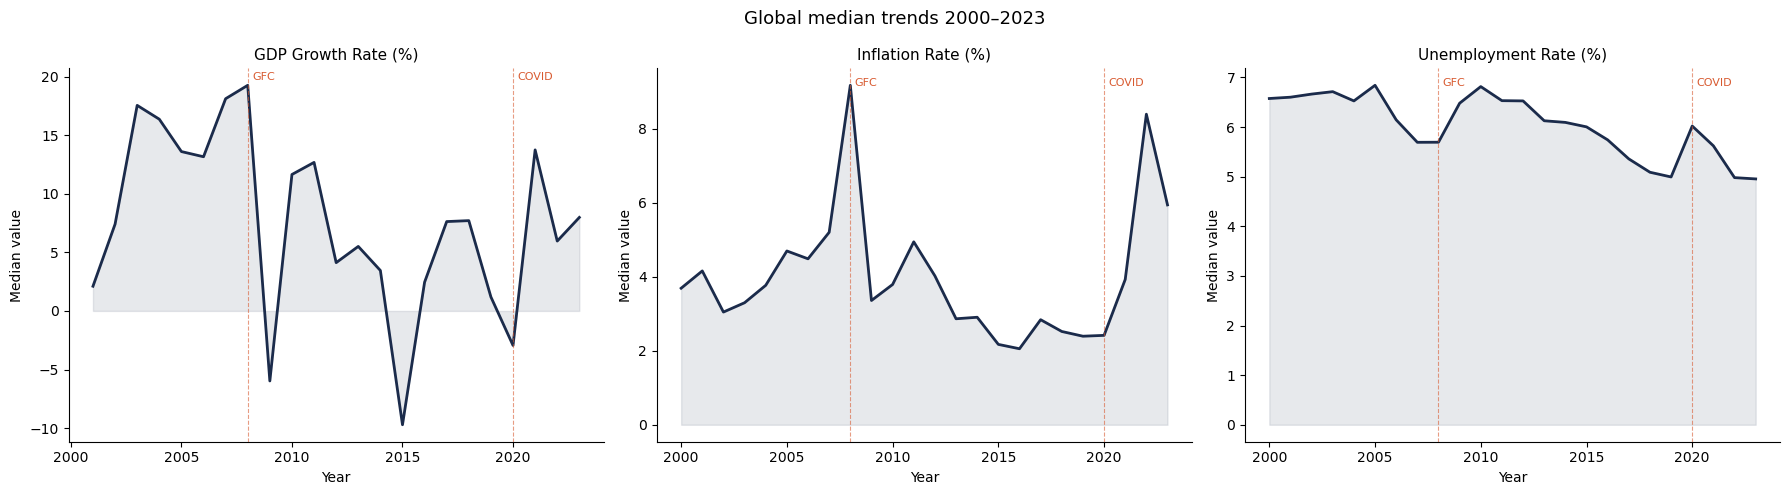

In [10]:
# ── 6. Time trends ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Global median trends 2000–2023', fontsize=13, fontweight='500')

indicators = {
    'gdp_growth_rate': 'GDP Growth Rate (%)',
    'inflation_rate': 'Inflation Rate (%)',
    'unemployment_rate': 'Unemployment Rate (%)',
}

for ax, (col, label) in zip(axes, indicators.items()):
    trend = df.groupby('year')[col].median()
    ax.plot(trend.index, trend.values, color='#1B2B4B', linewidth=2)
    ax.fill_between(trend.index, trend.values, alpha=0.1, color='#1B2B4B')
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.set_xlabel('Year')
    ax.set_ylabel('Median value')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Annotate key events
    ax.axvline(2008, color='#D85A30', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(2020, color='#D85A30', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.text(2008.2, ax.get_ylim()[1]*0.95, 'GFC', fontsize=8, color='#D85A30')
    ax.text(2020.2, ax.get_ylim()[1]*0.95, 'COVID', fontsize=8, color='#D85A30')

plt.tight_layout()
plt.savefig('05_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

Three global shocks are clearly visible across all three indicators:

**2008-2009 — Global Financial Crisis**
The most dramatic signal in the dataset. GDP growth collapsed from 
a median of ~19% in 2007 to -6% in 2009 — the sharpest single-year 
drop in the series. Inflation spiked to ~9% in 2008 (commodity price 
surge preceding the crash) then fell sharply. Unemployment ticked up 
and remained elevated through 2013-2014 as the recovery was slow and 
uneven across regions.

**2015-2016 — Commodity price collapse**
A secondary shock visible as a GDP growth dip around 2015-2016, 
largely driven by oil and commodity price falls hitting commodity-
exporting economies (Angola, Nigeria, Russia, Brazil, Gulf states) 
hard. Less dramatic than 2008 but persistent — explains several of 
the negative outliers in Section 3.

**2020-2022 — COVID-19 and post-pandemic inflation**
GDP growth dropped sharply in 2020 (global lockdowns) then rebounded 
strongly in 2021 as economies reopened. The most striking post-2020 
signal is inflation — rising from a median of ~2.5% pre-COVID to 
~8.5% in 2022, the highest level in the entire 2000-2023 series. 
This reflects global supply chain disruption, energy price spikes 
following the Ukraine war, and fiscal stimulus driving demand. 
Unemployment followed the inverse pattern — spike in 2020, 
gradual recovery through 2022-2023.

**Structural observation:** The GDP growth series shows high 
year-to-year volatility even outside of crisis periods. This 
volatility is one reason the regression model in Phase 10 is 
expected to have modest R² — GDP growth is genuinely difficult 
to predict from structural indicators alone, and short-term 
macroeconomic shocks (which our features don't capture) drive 
much of the year-to-year variation.

## 7. Crisis flag analysis

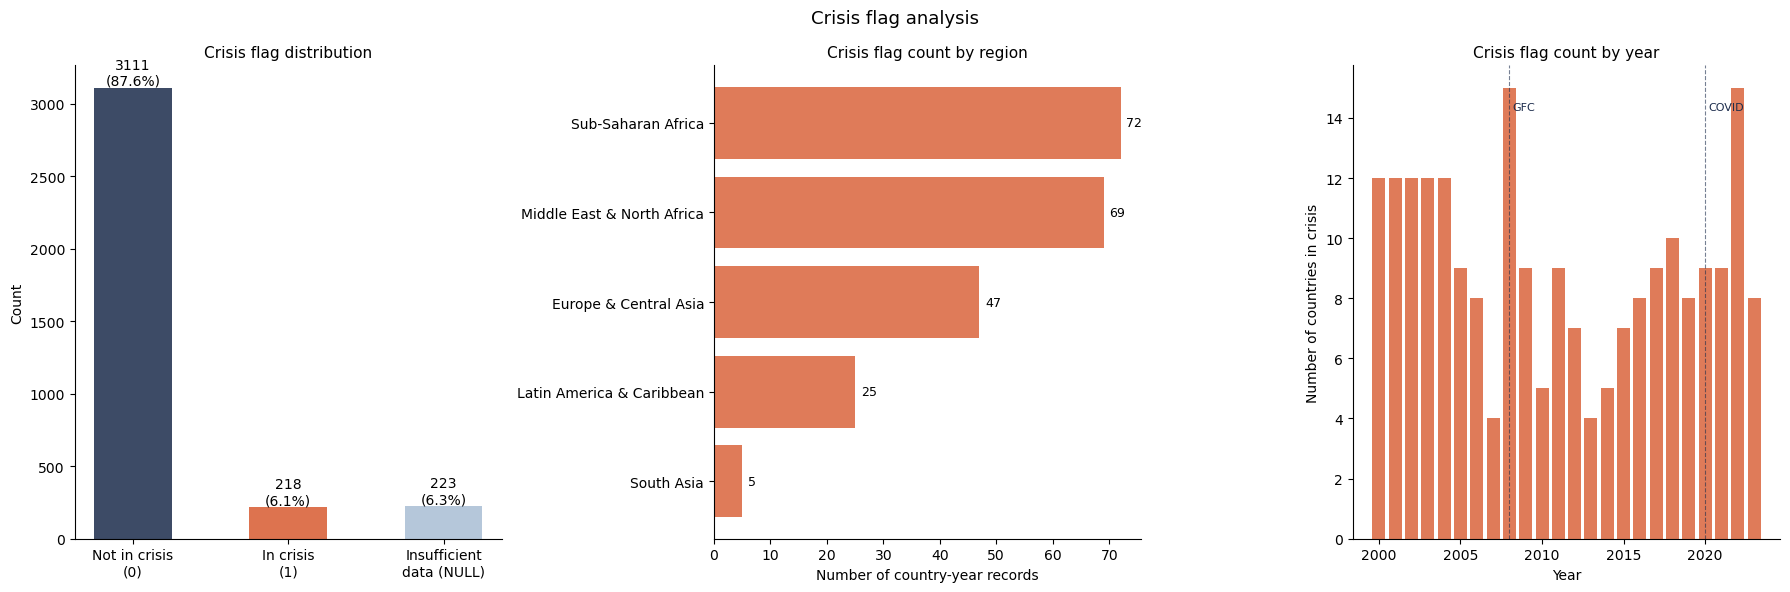


=== Crisis flag summary ===
Total rows: 3552
crisis_flag = 1: 218 (6.1%)
crisis_flag = 0: 3111 (87.6%)
crisis_flag = NULL: 223 (6.3%)

Top 10 countries by crisis years:
country_name
Iran           22
Angola         21
Sudan          16
Haiti          14
Turkey         11
Egypt          10
Yemen          10
Serbia         10
Syria           9
South Sudan     9
dtype: int64


In [12]:
# ── 7. Crisis flag analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Crisis flag analysis', fontsize=13, fontweight='500')

# Chart 1 — crisis flag distribution
ax = axes[0]
flag_counts = df['crisis_flag'].value_counts(dropna=False)
labels = ['Not in crisis\n(0)', 'In crisis\n(1)', 'Insufficient\ndata (NULL)']
values = [flag_counts.get(0.0, 0), flag_counts.get(1.0, 0), df['crisis_flag'].isna().sum()]
colors = ['#1B2B4B', '#D85A30', '#A8BDD4']
bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.5)
ax.set_title('Crisis flag distribution', fontsize=11, fontweight='500')
ax.set_ylabel('Count')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Chart 2 — crisis flags by region
ax = axes[1]
crisis_by_region = df[df['crisis_flag'] == 1].groupby('region').size()
crisis_by_region = crisis_by_region.sort_values(ascending=True)
ax.barh(crisis_by_region.index, crisis_by_region.values, color='#D85A30', alpha=0.8)
ax.set_title('Crisis flag count by region', fontsize=11, fontweight='500')
ax.set_xlabel('Number of country-year records')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, val in enumerate(crisis_by_region.values):
    ax.text(val + 1, i, str(val), va='center', fontsize=9)

# Chart 3 — crisis flags over time
ax = axes[2]
crisis_by_year = df[df['crisis_flag'] == 1].groupby('year').size()
ax.bar(crisis_by_year.index, crisis_by_year.values, color='#D85A30', alpha=0.8, width=0.8)
ax.set_title('Crisis flag count by year', fontsize=11, fontweight='500')
ax.set_xlabel('Year')
ax.set_ylabel('Number of countries in crisis')
ax.axvline(2008, color='#1B2B4B', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(2020, color='#1B2B4B', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(2008.2, crisis_by_year.max()*0.95, 'GFC', fontsize=8, color='#1B2B4B')
ax.text(2020.2, crisis_by_year.max()*0.95, 'COVID', fontsize=8, color='#1B2B4B')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('06_crisis_flags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Crisis flag summary ===")
print(f"Total rows: {len(df)}")
print(f"crisis_flag = 1: {(df['crisis_flag']==1).sum()} ({(df['crisis_flag']==1).sum()/len(df)*100:.1f}%)")
print(f"crisis_flag = 0: {(df['crisis_flag']==0).sum()} ({(df['crisis_flag']==0).sum()/len(df)*100:.1f}%)")
print(f"crisis_flag = NULL: {df['crisis_flag'].isna().sum()} ({df['crisis_flag'].isna().sum()/len(df)*100:.1f}%)")
print(f"\nTop 10 countries by crisis years:")
print(df[df['crisis_flag']==1].groupby('country_name').size().sort_values(ascending=False).head(10))

The `crisis_flag` marks country-years where both inflation AND unemployment 
were simultaneously elevated — a proxy for economic stress. Three states: 
`1` (in crisis), `0` (not in crisis), `NULL` (insufficient data to determine).

**Distribution**
218 rows (6.1%) are flagged as in crisis — a meaningful minority but 
heavily imbalanced relative to the 3,111 (87.6%) not-in-crisis rows. 
This class imbalance is the most important consideration for Phase 12 
(decision tree classifier) — a naive model that always predicts "not in 
crisis" would achieve 87.6% accuracy while being completely useless. 
`class_weight='balanced'` will be required.

**By region**
Sub-Saharan Africa (72) and Middle East & North Africa (69) account for 
the majority of crisis episodes — together representing 65% of all 
flagged records despite covering roughly 40% of countries. Europe & 
Central Asia (47) reflects the 2008-2009 financial crisis hitting 
transition economies hard. Notably, East Asia & Pacific and North America 
have zero or near-zero crisis flags — consistent with stronger monetary 
institutions and more diversified economies.

**By year**
Crisis flags are distributed across the full 2000-2023 period with no 
single dominant year — economic stress is a persistent condition for 
certain countries rather than a global synchronised event. Two visible 
peaks: around 2008-2009 (Global Financial Crisis) and 2021-2022 
(post-COVID inflation surge). The relatively high counts in 2000-2003 
reflect early-period crises in Argentina, Turkey, and several 
Sub-Saharan African states.

**Top countries by crisis years**
Iran leads with 22 crisis years out of 24 — chronic high inflation 
driven by sanctions and currency depreciation. Angola (21) reflects 
oil-dependent economic fragility. Sudan (16) and Haiti (14) reflect 
conflict and political instability. Turkey (11) shows recurring 
inflation episodes despite being an upper-middle-income economy.

**Modelling implication for Phase 12**
The crisis classifier faces a fundamentally imbalanced problem (6.1% 
positive class). Key decisions:
- Use `class_weight='balanced'` in the decision tree
- Evaluate on AUC-ROC and F1-score, not accuracy
- The NULL rows (6.3%) will be excluded from training — they cannot 
  be treated as either class without introducing bias

## 8. EDA summary and modelling decisions

Key findings from this exploratory analysis, and their direct implications 
for Phases 10-12:

### Data quality
- Dataset is largely complete (92-99% non-null across key indicators)
- No critical data gaps that would prevent modelling
- `crisis_flag` NULL values (6.3%) are deliberate — insufficient data, 
  not imputable. Exclude from classification training.

### Distributions and transformations required
| Column | Issue | Treatment |
|---|---|---|
| `inflation_rate` | Severely right-skewed, 500%+ outliers | Log transform before regression |
| `population` | Extremely right-skewed | Log transform before regression |
| `gdp_growth_rate` | Long tails, known artifacts | Winsorise at 1st/99th percentile |
| `log_gdp` | Already log-transformed in dbt | Use as-is |
| `income_group_enc` | Correlated with log_gdp (0.59) | Use one or the other in regression |

### Known anomalies
| Country | Year | Value | Classification |
|---|---|---|---|
| Sierra Leone | 2001 | +164.4% GDP growth | Real — post-civil-war rebound. Retain. |
| Ghana | 2006 | +94.4% GDP growth | Statistical artifact — GDP rebasing. Handled by winsorisation. |
| Venezuela | multiple | Extreme negative growth | Real — economic collapse. Retain. |
| Lebanon | 2020-2023 | Extreme inflation + negative growth | Real — banking/currency crisis. Retain. |

### Feature recommendations for modelling
- **Regression (Phase 10):** `log_gdp`, `inflation_rate` (log), `unemployment_rate`, 
  `exports_pct_gdp`, `region` (encoded), `year` as features → predict `gdp_growth_rate`
- **Clustering (Phase 11):** `log_gdp`, `income_group_enc`, `exports_pct_gdp`, 
  `inflation_rate` (log), `unemployment_rate` → segment countries into archetypes
- **Classification (Phase 12):** All indicators → predict `crisis_flag`, 
  with `class_weight='balanced'` and AUC-ROC as primary metric

### Baseline expectations
- Regression R² likely modest (0.3-0.5) — GDP growth is driven by short-term 
  macroeconomic shocks our features don't capture
- Clustering likely reveals 3-5 meaningful country archetypes aligned 
  broadly with income group and region
- Classification AUC likely 0.75-0.85 given the clear structural 
  differences between crisis and non-crisis country-years